#Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


#Downloading dataset

In [2]:
!wget -q https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip -q -o jena_climate_2009_2016.csv.zip
df = pd.read_csv("jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


#Preprocessing

In [3]:
n_rows = len(df) // 6 * 6
df = df.iloc[:n_rows]

df = df.groupby(df.index // 6).mean(numeric_only=True)
df = df.reset_index(drop=True)

feature_cols = [
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

target_col = "T (degC)"

features = df[feature_cols].values.astype(np.float32)
target = df[target_col].values.astype(np.float32)

n = len(features)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

feature_mean = features[:train_end].mean(axis=0)
feature_std = features[:train_end].std(axis=0)
feature_std[feature_std == 0] = 1

features_norm = (features - feature_mean) / feature_std

target_mean = target[:train_end].mean()
target_std = target[:train_end].std()
if target_std == 0:
    target_std = 1

target_norm = (target - target_mean) / target_std

#Build sliding windows

In [4]:
INPUT_LEN = 72
OUTPUT_LEN = 12

def make_windows(features, target, input_len, output_len):
    X = []
    Y = []
    for i in range(len(features) - input_len - output_len + 1):
        X.append(features[i:i + input_len])
        Y.append(target[i + input_len:i + input_len + output_len])
    return np.array(X), np.array(Y)

train_features = features_norm[:train_end]
val_features = features_norm[train_end:val_end]
test_features = features_norm[val_end:]

train_target = target_norm[:train_end]
val_target = target_norm[train_end:val_end]
test_target = target_norm[val_end:]

X_train, Y_train = make_windows(train_features, train_target, INPUT_LEN, OUTPUT_LEN)
X_val, Y_val = make_windows(val_features, val_target, INPUT_LEN, OUTPUT_LEN)
X_test, Y_test = make_windows(test_features, test_target, INPUT_LEN, OUTPUT_LEN)

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

(48980, 72, 6) (48980, 12)
(10431, 72, 6) (10431, 12)
(10431, 72, 6) (10431, 12)


#Dataset and DataLoader

In [5]:
from torch.utils.data import Dataset, DataLoader

class WeatherDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

BATCH_SIZE = 128

train_loader = DataLoader(WeatherDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WeatherDataset(X_val, Y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(WeatherDataset(X_test, Y_test), batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([128, 72, 6]) torch.Size([128, 12])


#Custom LSTM cell and model

In [6]:
class CustomLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.W = nn.Parameter(torch.empty(4 * hidden_size, input_size))
        self.U = nn.Parameter(torch.empty(4 * hidden_size, hidden_size))
        self.b = nn.Parameter(torch.zeros(4 * hidden_size))

        nn.init.xavier_uniform_(self.W)
        nn.init.orthogonal_(self.U)

        with torch.no_grad():
            self.b[hidden_size:2 * hidden_size].fill_(1.0)

    def forward(self, x_t, h_prev, c_prev):
        gates = x_t @ self.W.T + h_prev @ self.U.T + self.b
        i_t, f_t, g_t, o_t = gates.chunk(4, dim=1)

        i_t = torch.sigmoid(i_t)
        f_t = torch.sigmoid(f_t)
        g_t = torch.tanh(g_t)
        o_t = torch.sigmoid(o_t)

        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)

        return h_t, c_t

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size

        self.lstm1 = CustomLSTM(input_size, hidden_size)
        self.lstm2 = CustomLSTM(hidden_size, hidden_size)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        h1 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c1 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        h2 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c2 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        for t in range(seq_len):
            x_t = x[:, t, :]
            h1, c1 = self.lstm1(x_t, h1, c1)
            h1 = self.dropout(h1)
            h2, c2 = self.lstm2(h1, h2, c2)

        return self.fc(h2)

#Transformer components

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / np.sqrt(self.d_k)
        attn_weights = torch.softmax(scores, dim=-1)
        attn_out = attn_weights @ V

        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        return self.W_o(attn_out)

class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.2):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout1 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        attn_out = self.attn(x)
        x = self.norm1(x + self.dropout1(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x

class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model=64, num_heads=4, d_ff=None, num_layers=3, output_len=12, max_len=1000, dropout=0.1):
        super().__init__()
        if d_ff is None:
            d_ff = d_model * 4

        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len)
        self.input_dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([EncoderBlock(d_model, num_heads, d_ff) for _ in range(num_layers)])
        self.output_head = nn.Linear(d_model, output_len)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.input_dropout(x)
        for block in self.blocks:
            x = block(x)
        x = x[:, -1, :]
        return self.output_head(x)

#Train and eval functions



In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)
    return total_loss / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss = criterion(preds, yb)
        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)
    return total_loss / total

def set_lr(optimizer, lr):
    for param_group in optimizer.param_groups:
        param_group["lr"] = lr

def train_model(model, train_loader, val_loader, device, epochs=25, target_lr=1e-3, weight_decay=5e-4, warmup_epochs=5):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=target_lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        if epoch <= warmup_epochs:
            set_lr(optimizer, target_lr * (epoch / warmup_epochs))

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, val_loader, criterion, device)

        if epoch > warmup_epochs:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch}/{epochs} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f}")

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, history, best_val_loss

#LSTM Training Loop

In [9]:
lstm_model = LSTMModel(input_size=len(feature_cols), hidden_size=64, output_size=OUTPUT_LEN).to(device)
lstm_model, lstm_history, lstm_best_val = train_model(lstm_model, train_loader, val_loader, device, epochs=25, target_lr=1e-3, weight_decay=5e-4)

Epoch 1/25 | train_loss 0.3093 | val_loss 0.1376
Epoch 2/25 | train_loss 0.0990 | val_loss 0.0876
Epoch 3/25 | train_loss 0.0792 | val_loss 0.0763
Epoch 4/25 | train_loss 0.0701 | val_loss 0.0712
Epoch 5/25 | train_loss 0.0654 | val_loss 0.0707
Epoch 6/25 | train_loss 0.0624 | val_loss 0.0645
Epoch 7/25 | train_loss 0.0604 | val_loss 0.0607
Epoch 8/25 | train_loss 0.0589 | val_loss 0.0612
Epoch 9/25 | train_loss 0.0579 | val_loss 0.0617
Epoch 10/25 | train_loss 0.0569 | val_loss 0.0610
Epoch 11/25 | train_loss 0.0547 | val_loss 0.0609
Epoch 12/25 | train_loss 0.0544 | val_loss 0.0604
Epoch 13/25 | train_loss 0.0540 | val_loss 0.0585
Epoch 14/25 | train_loss 0.0540 | val_loss 0.0587
Epoch 15/25 | train_loss 0.0534 | val_loss 0.0588
Epoch 16/25 | train_loss 0.0533 | val_loss 0.0574
Epoch 17/25 | train_loss 0.0530 | val_loss 0.0578
Epoch 18/25 | train_loss 0.0527 | val_loss 0.0577
Epoch 19/25 | train_loss 0.0521 | val_loss 0.0575
Epoch 20/25 | train_loss 0.0512 | val_loss 0.0583
Epoch 21/

#Transformer training loop

In [10]:
transformer_model = TransformerModel(
    input_size=len(feature_cols),
    d_model=64,
    num_heads=4,
    num_layers=3,
    output_len=OUTPUT_LEN,
    max_len=INPUT_LEN
).to(device)

transformer_model, transformer_history, transformer_best_val = train_model(transformer_model, train_loader, val_loader, device, epochs=25, target_lr=5e-4, weight_decay=5e-4)

Epoch 1/25 | train_loss 0.2744 | val_loss 0.1139
Epoch 2/25 | train_loss 0.1049 | val_loss 0.0730
Epoch 3/25 | train_loss 0.0813 | val_loss 0.0724
Epoch 4/25 | train_loss 0.0727 | val_loss 0.0713
Epoch 5/25 | train_loss 0.0674 | val_loss 0.0709
Epoch 6/25 | train_loss 0.0654 | val_loss 0.0693
Epoch 7/25 | train_loss 0.0628 | val_loss 0.0642
Epoch 8/25 | train_loss 0.0612 | val_loss 0.0753
Epoch 9/25 | train_loss 0.0603 | val_loss 0.0692
Epoch 10/25 | train_loss 0.0590 | val_loss 0.0691
Epoch 11/25 | train_loss 0.0576 | val_loss 0.0631
Epoch 12/25 | train_loss 0.0572 | val_loss 0.0616
Epoch 13/25 | train_loss 0.0564 | val_loss 0.0647
Epoch 14/25 | train_loss 0.0566 | val_loss 0.0666
Epoch 15/25 | train_loss 0.0560 | val_loss 0.0680
Epoch 16/25 | train_loss 0.0552 | val_loss 0.0636
Epoch 17/25 | train_loss 0.0551 | val_loss 0.0607
Epoch 18/25 | train_loss 0.0549 | val_loss 0.0620
Epoch 19/25 | train_loss 0.0547 | val_loss 0.0633
Epoch 20/25 | train_loss 0.0546 | val_loss 0.0612
Epoch 21/

#Loss curves

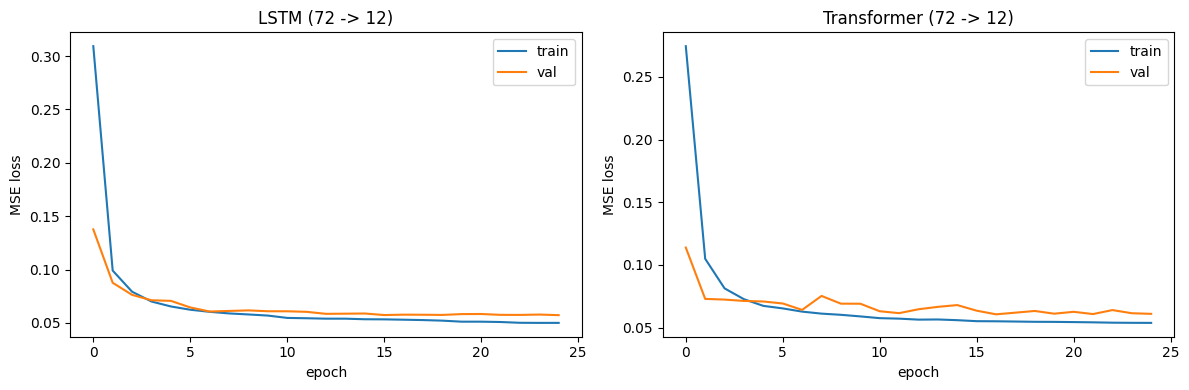

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lstm_history["train_loss"], label="train")
axes[0].plot(lstm_history["val_loss"], label="val")
axes[0].set_title("LSTM (72 -> 12)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()

axes[1].plot(transformer_history["train_loss"], label="train")
axes[1].plot(transformer_history["val_loss"], label="val")
axes[1].set_title("Transformer (72 -> 12)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("MSE loss")
axes[1].legend()

plt.tight_layout()
plt.show()

#Getting the test set



In [12]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.numpy())
    all_preds = np.concatenate(all_preds, axis=0) * target_std + target_mean
    all_targets = np.concatenate(all_targets, axis=0) * target_std + target_mean
    return all_preds, all_targets

lstm_preds, lstm_targets = get_predictions(lstm_model, test_loader, device)
transformer_preds, transformer_targets = get_predictions(transformer_model, test_loader, device)

print(lstm_preds.shape, transformer_preds.shape)

(10431, 12) (10431, 12)


#Metrics table (MAE, RMSE, R2, correlation, best/median/worst per-window MAE)

In [13]:
def compute_metrics(preds, targets):
    errors = preds - targets
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt((errors ** 2).mean())
    r2 = r2_score(targets.flatten(), preds.flatten())
    corr = np.corrcoef(targets.flatten(), preds.flatten())[0, 1]

    per_window_mae = abs_errors.mean(axis=1)
    best_mae = per_window_mae.min()
    median_mae = np.median(per_window_mae)
    worst_mae = per_window_mae.max()

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Correlation": corr,
        "Best MAE": best_mae,
        "Median MAE": median_mae,
        "Worst MAE": worst_mae
    }

lstm_metrics = compute_metrics(lstm_preds, lstm_targets)
transformer_metrics = compute_metrics(transformer_preds, transformer_targets)

metrics_df = pd.DataFrame({
    "LSTM": lstm_metrics,
    "Transformer": transformer_metrics
})

def pick_better(row, higher_is_better):
    if higher_is_better:
        return "LSTM" if row["LSTM"] > row["Transformer"] else "Transformer"
    else:
        return "LSTM" if row["LSTM"] < row["Transformer"] else "Transformer"

higher_better_metrics = {"R2", "Correlation"}
metrics_df["Better"] = [
    pick_better(metrics_df.loc[m], m in higher_better_metrics)
    for m in metrics_df.index
]

metrics_df.round(4)

,LSTM,Transformer,Better
MAE,1.4627,1.4152,Transformer
RMSE,1.9576,1.9130,Transformer
R2,0.9369,0.9398,Transformer
Correlation,0.9683,0.9698,Transformer
Best MAE,0.1008,0.0826,Transformer
Median MAE,1.2510,1.2071,Transformer
Worst MAE,9.9659,7.6908,Transformer


#Error Threshold Table

In [14]:
def error_threshold_counts(preds, targets, thresholds):
    abs_errors = np.abs(preds - targets).flatten()
    return [int((abs_errors > t).sum()) for t in thresholds]

thresholds = [1, 2, 3, 4, 5, 6]

lstm_counts = error_threshold_counts(lstm_preds, lstm_targets, thresholds)
transformer_counts = error_threshold_counts(transformer_preds, transformer_targets, thresholds)

threshold_df = pd.DataFrame({
    "Error Threshold": [f"> {t}°C" for t in thresholds],
    "LSTM": lstm_counts,
    "Transformer": transformer_counts
})

threshold_df

,Error Threshold,LSTM,Transformer
0,> 1°C,67836,65100
1,> 2°C,32435,31089
2,> 3°C,14604,13962
3,> 4°C,6293,5953
4,> 5°C,2633,2570
5,> 6°C,1084,1123


#Predicted vs Actual

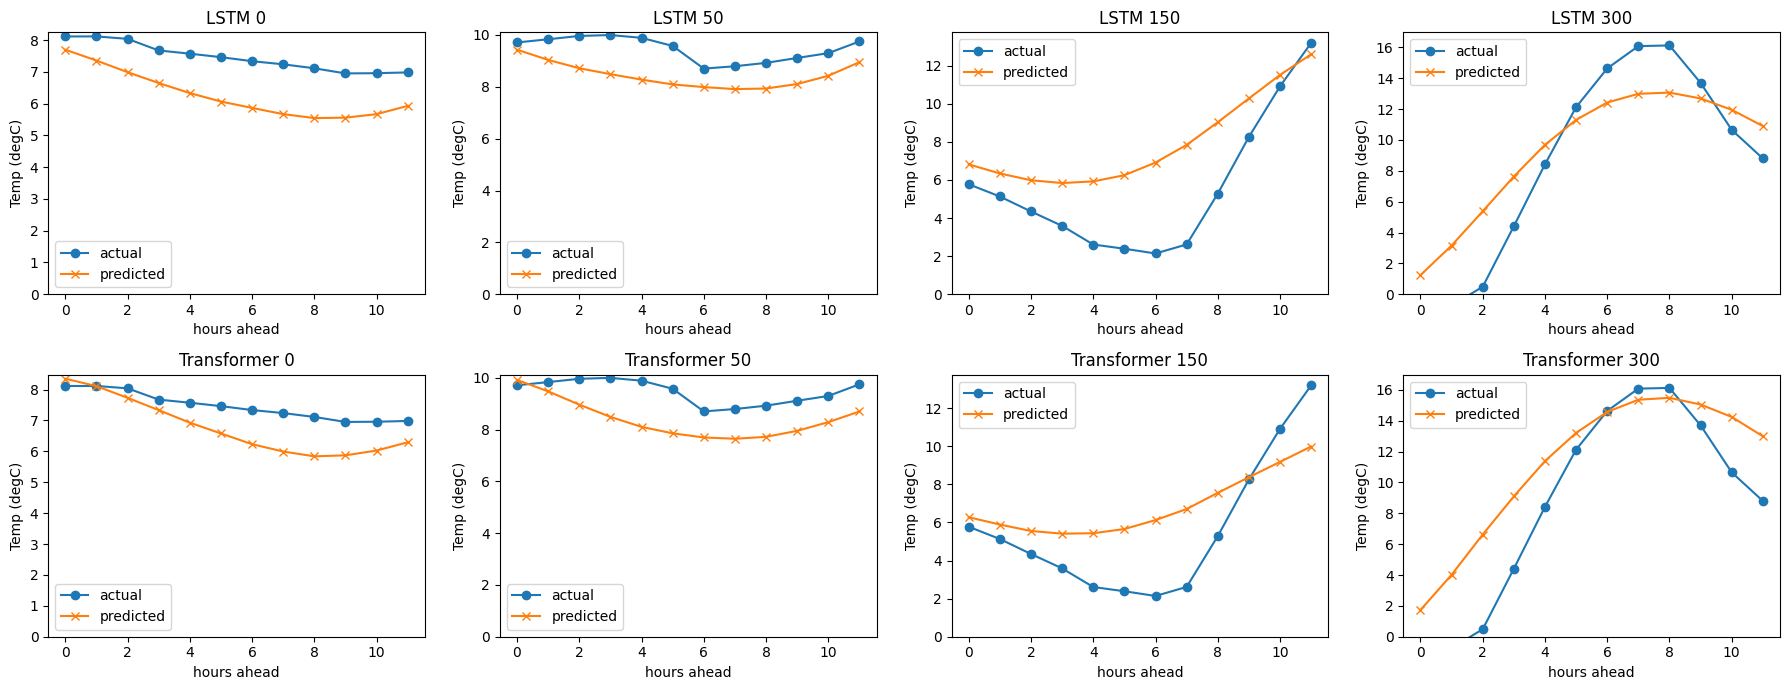

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

sample_indices = [0, 50, 150, 300]

for col, idx in enumerate(sample_indices):
    axes[0, col].plot(lstm_targets[idx], label="actual", marker="o")
    axes[0, col].plot(lstm_preds[idx], label="predicted", marker="x")
    axes[0, col].set_title(f"LSTM {idx}")
    axes[0, col].set_xlabel("hours ahead")
    axes[0, col].set_ylabel("Temp (degC)")
    axes[0, col].set_ylim(bottom=0)
    axes[0, col].legend()

    axes[1, col].plot(transformer_targets[idx], label="actual", marker="o")
    axes[1, col].plot(transformer_preds[idx], label="predicted", marker="x")
    axes[1, col].set_title(f"Transformer {idx}")
    axes[1, col].set_xlabel("hours ahead")
    axes[1, col].set_ylabel("Temp (degC)")
    axes[1, col].set_ylim(bottom=0)
    axes[1, col].legend()

plt.tight_layout()
plt.show()

#Save Weights

In [20]:
torch.save(lstm_model.state_dict(), "comparison_lstm.pth")
torch.save(transformer_model.state_dict(), "comparison_transformer.pth")
print("saved")

saved
